# Mean-Variance Optimization (MVO) Portfolio — In-Sample vs Out-of-Sample

**Addressing the Professor's Feedback on Estimation Error:**
> *"In theory, MVO should outperform equal weighting if the estimated expected returns... are sufficiently accurate. However, in practice, MVO is very sensitive to estimation error... I am wondering, in the in-sample results, how the equal-weighted portfolio compares with the MVO-weighted portfolio."*

**Methodology Update:**
To investigate this, we now calculate two sets of returns for each month $T$:
1. **In-Sample (Ex-Ante Expected) Return:** Calculated using the model's *predicted returns* for month $T+1$ ($\hat{\mu}$). This shows the optimizer's "illusion" of performance. MVO will naturally dominate here because it aggressively overweights the highest predictions.
2. **Out-of-Sample (Ex-Post Realized) Return:** Calculated using the *actual realized returns* for month $T+1$ ($y_{next}$). This shows reality. If predictions contain noise (estimation error), MVO's heavy tilts will backfire, causing it to underperform the more robust Naive/Equal-Weight portfolio.

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)

In [10]:
# =============================================================================
# 1. Load Data
# =============================================================================
# ── Adjust paths to your local setup ──────────────────────────────────────────
try:
    top6_ols = pd.read_csv('new_ols_top6_by_month_post2022.csv')
    top6_rf  = pd.read_csv('rf_top6_by_month_post2022.csv')
except FileNotFoundError:
    print("Please ensure the CSV files are in the correct directory.")

top6_ols['MthCalDt'] = pd.to_datetime(top6_ols['MthCalDt'])
top6_rf['MthCalDt']  = pd.to_datetime(top6_rf['MthCalDt'])

print('OLS shape:', top6_ols.shape,
      '| months:', top6_ols['DateKey'].nunique(),
      '| unique stocks:', top6_ols['PERMNO'].nunique())
print('RF  shape:', top6_rf.shape,
      '| months:', top6_rf['DateKey'].nunique(),
      '| unique stocks:', top6_rf['PERMNO'].nunique())

# Verify month alignment
ols_months = set(top6_ols['DateKey'].unique())
rf_months  = set(top6_rf['DateKey'].unique())
assert ols_months == rf_months, 'Month mismatch between OLS and RF datasets'
print(f'Month alignment: OK — {len(ols_months)} months, {min(ols_months)} to {max(ols_months)}')

OLS shape: (282, 26) | months: 47 | unique stocks: 230
RF  shape: (282, 26) | months: 47 | unique stocks: 99
Month alignment: OK — 47 months, 202201 to 202511


In [11]:
# =============================================================================
# 2. MVO Core Functions
# =============================================================================
N          = 6
WEIGHT_CAP = 1 / (N / 2)   # = 1/3 ≈ 0.3333 weight limit per stock
COV_WINDOW = 36            # Rolling 36-month window for variance

print(f'Weight cap: 1/(N/2) = 1/({N}/2) = {WEIGHT_CAP:.4f}')

def max_sharpe_weights(mu, cov, weight_cap):
    """Solves for maximum Sharpe Ratio weights subject to constraints."""
    n   = len(mu)
    w0  = np.ones(n) / n
    cov_reg = cov + np.eye(n) * 1e-6

    def neg_sharpe(w):
        ret = w @ mu
        vol = np.sqrt(max(w @ cov_reg @ w, 1e-12))
        return -ret / vol

    result = minimize(
        neg_sharpe, w0,
        method='SLSQP',
        bounds=[(0.0, weight_cap)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}],
        options={'ftol': 1e-9, 'maxiter': 1000}
    )

    if result.success:
        w = np.clip(result.x, 0, weight_cap)
        return w / w.sum()
    return w0

def build_diagonal_cov(df, permnos, hist_months):
    """Builds a diagonal covariance matrix using rolling return variances."""
    variances = []
    for p in permnos:
        h = df[(df['PERMNO'] == p) & (df['DateKey'].isin(hist_months))]['MthRet']
        variances.append(h.var() if len(h) >= 2 else (0.20 / np.sqrt(12)) ** 2)
    return np.diag(variances)

def rank_transform_mu(mu_raw, scale=0.10):
    """Transforms raw signals into cross-sectional rank scores mapped to [0, scale]."""
    ranks = mu_raw.argsort().argsort().astype(float)
    return (ranks / max(ranks.max(), 1)) * scale

Weight cap: 1/(N/2) = 1/(6/2) = 0.3333


In [12]:
# =============================================================================
# 3. Monthly MVO Loop (With In-Sample vs Out-of-Sample Tracking)
# =============================================================================
def run_mvo_is_oos(top6_df, label, weight_cap=WEIGHT_CAP, cov_window=COV_WINDOW):
    all_months = sorted(top6_df['DateKey'].unique())

    datekeys = []
    ret_oos_mvo, ret_oos_ew = [], [] # Out-of-Sample (Reality)
    ret_is_mvo,  ret_is_ew  = [], [] # In-Sample (Expectation)

    for i, month in enumerate(all_months):
        md      = top6_df[top6_df['DateKey'] == month]
        permnos = md['PERMNO'].tolist()

        # mu_raw is the model prediction (In-Sample Expectation)
        # y_next is the actual realized return (Out-of-Sample Reality)
        mu_raw  = md['predicted_return'].values
        y_next  = md['y_next'].values

        mu_sc = rank_transform_mu(mu_raw)

        start       = max(0, i - cov_window)
        hist_months = all_months[start:i]
        cov = build_diagonal_cov(top6_df, permnos, hist_months)

        # 1. Generate Weights
        w_ew = np.ones(len(permnos)) / len(permnos)
        if i == 0:
            w_mvo = w_ew # First month fallback
        else:
            w_mvo = max_sharpe_weights(mu_sc, cov, weight_cap)

        # 2. Out-of-Sample (OOS) Return: Weights * Actual Next Month Returns
        ret_oos_mvo.append(float(w_mvo @ y_next))
        ret_oos_ew.append( float(w_ew  @ y_next))

        # 3. In-Sample (IS) Return: Weights * Predicted Returns
        # This shows what the optimizer *thought* it was going to earn
        ret_is_mvo.append(float(w_mvo @ mu_raw))
        ret_is_ew.append( float(w_ew  @ mu_raw))

        datekeys.append(month)

    print(f'[{label}] Backtest Done. {len(datekeys)} months processed.')
    return datekeys, ret_oos_mvo, ret_oos_ew, ret_is_mvo, ret_is_ew

# Run backtests for both models
dk_ols, ols_oos_mvo, ols_oos_ew, ols_is_mvo, ols_is_ew = run_mvo_is_oos(top6_ols, label='OLS')
dk_rf,  rf_oos_mvo,  rf_oos_ew,  rf_is_mvo,  rf_is_ew  = run_mvo_is_oos(top6_rf,  label='RF')

[OLS] Backtest Done. 47 months processed.
[RF] Backtest Done. 47 months processed.


In [13]:
# =============================================================================
# 4. Performance Summary (Out-of-Sample)
# =============================================================================
def performance_metrics(ret_series, label=''):
    r = np.array(ret_series)
    T = len(r)
    if T == 0: return {}
    ann_ret = (1 + r).prod() ** (12 / T) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe  = (r.mean() / r.std()) * np.sqrt(12) if r.std() > 0 else 0
    wealth  = (1 + r).cumprod()
    peak    = np.maximum.accumulate(wealth)
    mdd     = ((peak - wealth) / peak).max()
    return {'Portfolio'   : label,
            'Ann. Return' : f'{ann_ret:.2%}',
            'Ann. Vol'    : f'{ann_vol:.2%}',
            'Sharpe Ratio': f'{sharpe:.4f}',
            'Max Drawdown': f'{mdd:.2%}'}

metrics = [
    performance_metrics(ols_oos_mvo, 'OLS + MVO (Realized)'),
    performance_metrics(rf_oos_mvo,  'RF  + MVO (Realized)'),
    performance_metrics(ols_oos_ew,  'Equal-Weight OLS (Realized)'),
    performance_metrics(rf_oos_ew,   'Equal-Weight RF (Realized)'),
]

print('=== OUT-OF-SAMPLE PERFORMANCE TABLE ===')
display(pd.DataFrame(metrics).set_index('Portfolio'))

=== OUT-OF-SAMPLE PERFORMANCE TABLE ===


,Ann. Return,Ann. Vol,Sharpe Ratio,Max Drawdown
Portfolio,,,,
OLS + MVO (Realized),6.08%,36.85%,0.3457,45.62%
RF + MVO (Realized),19.34%,17.57%,1.1009,14.29%
Equal-Weight OLS (Realized),2.73%,31.10%,0.2464,31.47%
Equal-Weight RF (Realized),22.42%,18.07%,1.2200,18.28%


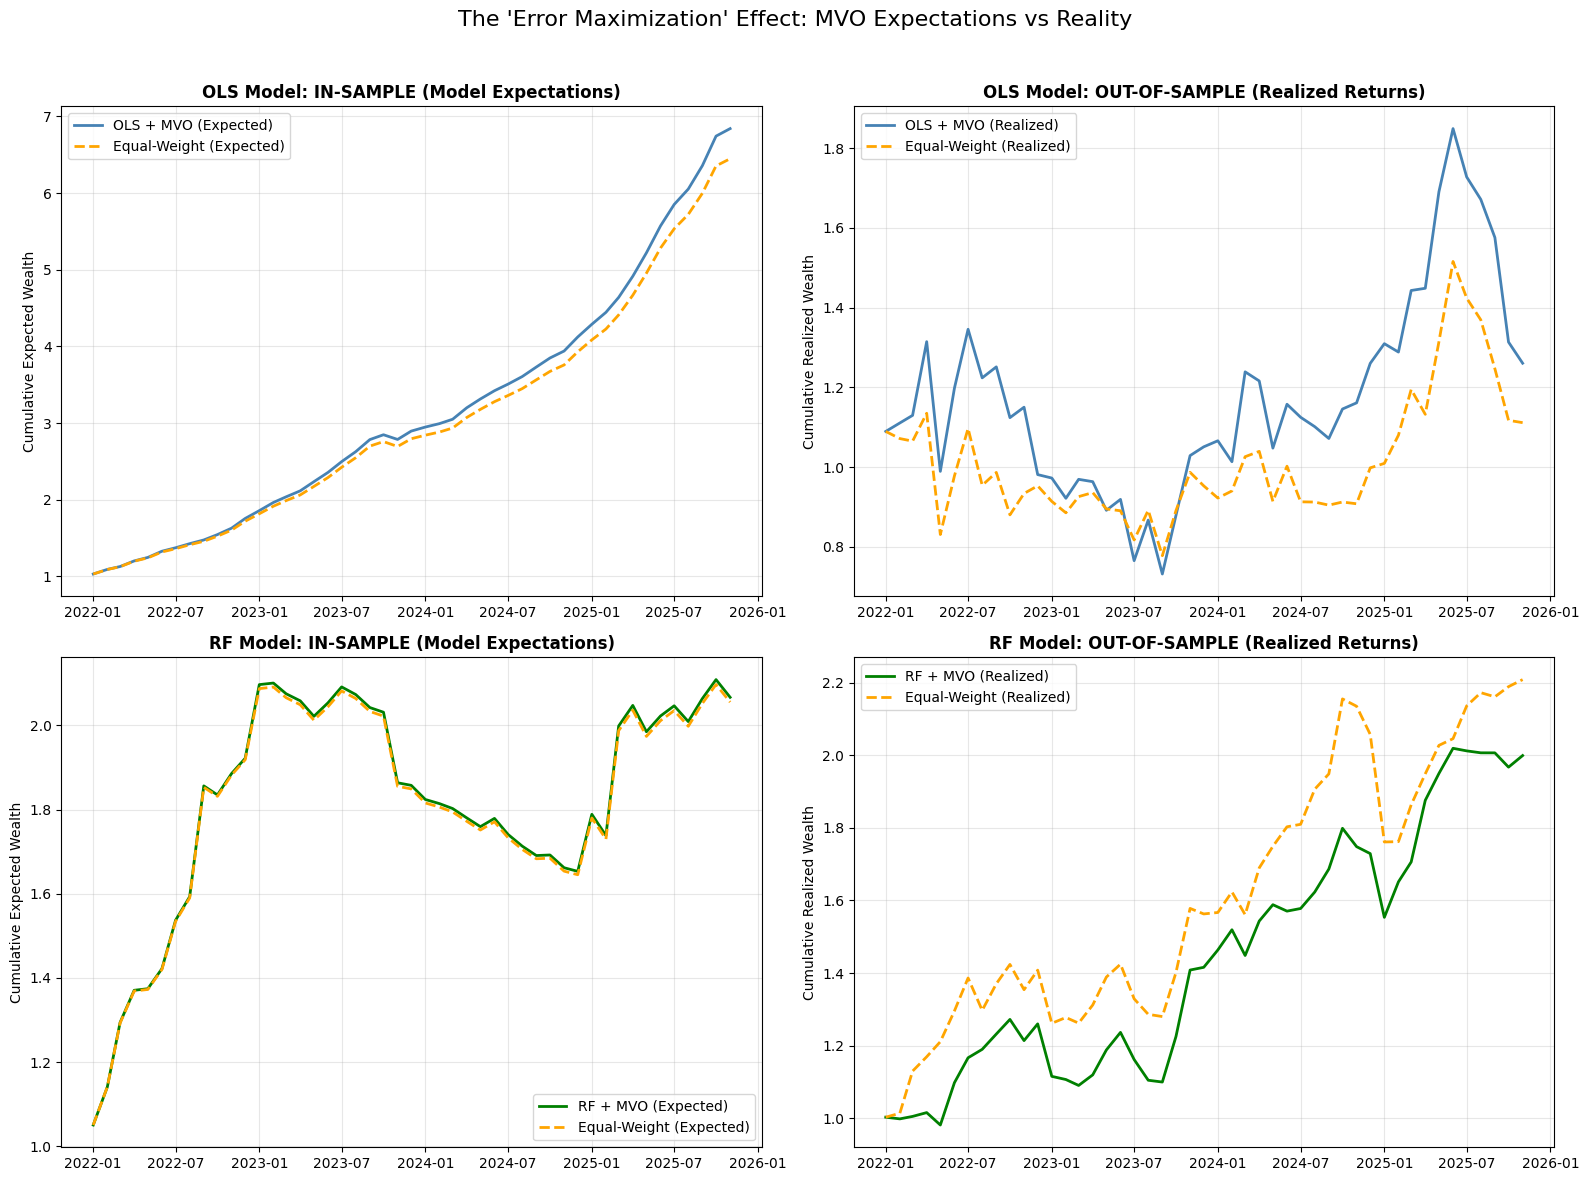

In [14]:
# =============================================================================
# 5. Visualizing the Error Maximization Effect (IS vs OOS)
# =============================================================================
months = pd.to_datetime(pd.Series(dk_ols).astype(str), format='%Y%m')

# Create a 2x2 grid for OLS and RF, showing In-Sample vs Out-of-Sample side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- ROW 1: OLS MODEL ---
# OLS In-Sample (Expectation)
ax = axes[0, 0]
ax.plot(months, (1 + pd.Series(ols_is_mvo)).cumprod(), label='OLS + MVO (Expected)', color='steelblue', lw=2)
ax.plot(months, (1 + pd.Series(ols_is_ew)).cumprod(), label='Equal-Weight (Expected)', color='orange', ls='--', lw=2)
ax.set_title('OLS Model: IN-SAMPLE (Model Expectations)', fontweight='bold')
ax.set_ylabel('Cumulative Expected Wealth')
ax.legend(); ax.grid(True, alpha=0.3)

# OLS Out-of-Sample (Reality)
ax = axes[0, 1]
ax.plot(months, (1 + pd.Series(ols_oos_mvo)).cumprod(), label='OLS + MVO (Realized)', color='steelblue', lw=2)
ax.plot(months, (1 + pd.Series(ols_oos_ew)).cumprod(), label='Equal-Weight (Realized)', color='orange', ls='--', lw=2)
ax.set_title('OLS Model: OUT-OF-SAMPLE (Realized Returns)', fontweight='bold')
ax.set_ylabel('Cumulative Realized Wealth')
ax.legend(); ax.grid(True, alpha=0.3)

# --- ROW 2: RANDOM FOREST MODEL ---
# RF In-Sample (Expectation)
ax = axes[1, 0]
ax.plot(months, (1 + pd.Series(rf_is_mvo)).cumprod(), label='RF + MVO (Expected)', color='green', lw=2)
ax.plot(months, (1 + pd.Series(rf_is_ew)).cumprod(), label='Equal-Weight (Expected)', color='orange', ls='--', lw=2)
ax.set_title('RF Model: IN-SAMPLE (Model Expectations)', fontweight='bold')
ax.set_ylabel('Cumulative Expected Wealth')
ax.legend(); ax.grid(True, alpha=0.3)

# RF Out-of-Sample (Reality)
ax = axes[1, 1]
ax.plot(months, (1 + pd.Series(rf_oos_mvo)).cumprod(), label='RF + MVO (Realized)', color='green', lw=2)
ax.plot(months, (1 + pd.Series(rf_oos_ew)).cumprod(), label='Equal-Weight (Realized)', color='orange', ls='--', lw=2)
ax.set_title('RF Model: OUT-OF-SAMPLE (Realized Returns)', fontweight='bold')
ax.set_ylabel('Cumulative Realized Wealth')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("The 'Error Maximization' Effect: MVO Expectations vs Reality", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('is_vs_oos_wealth_curves.png', dpi=150, bbox_inches='tight')
plt.show()